<a href="https://colab.research.google.com/github/kgpgaurav/Music_genre/blob/main/STFT_music_genre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/gtzan/Data/genres_original"

In [ ]:
def load_and_preprocess_data(data_dir, classes, target_shape=(150, 150), file_limit=20):
    data = []
    labels = []

    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print(f"\nProcessing class: {class_name}")


        for filename in os.listdir(class_dir):
            file_path = os.path.join(class_dir, filename)
            try:
                audio_data, sample_rate = librosa.load(file_path, sr=None)
            except Exception as e:
                print(f"Skipping corrupted file: {file_path} - Error: {e}")
                continue

            chunk_duration = 4  # seconds
            overlap_duration = 2  # seconds
            chunk_samples = chunk_duration * sample_rate
            overlap_samples = overlap_duration * sample_rate

            num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

            for i in range(num_chunks):
                start = i * (chunk_samples - overlap_samples)
                end = start + chunk_samples
                chunk = audio_data[start:end]

                # Compute STFT
                stft = np.abs(librosa.stft(chunk, n_fft=1024, hop_length=512))
                stft_db = librosa.amplitude_to_db(stft, ref=np.max)

                # Resize to target shape
                stft_db = resize(np.expand_dims(stft_db, axis=-1), target_shape)

                # Append data
                data.append(stft_db)
                labels.append(i_class)


    return np.array(data), np.array(labels)

In [ ]:
data_dir = BASE_DIR
classes = ['blues', 'classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']

In [ ]:
data,labels = load_and_preprocess_data(data_dir,classes)


Processing class: blues

Processing class: classical

Processing class: country

Processing class: disco

Processing class: hiphop

Processing class: jazz


<ipython-input-14-7fc89f964fa4>:13: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_data, sample_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping corrupted file: /content/drive/MyDrive/gtzan/Data/genres_original/jazz/jazz.00054.wav - Error: 

Processing class: metal

Processing class: pop

Processing class: reggae

Processing class: rock


In [ ]:
print(data.shape)
print(labels.shape)

(14975, 150, 150, 1)
(14975,)


In [ ]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels,num_classes=len(classes))
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(data,labels,test_size=0.2,random_state=42)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(11980, 150, 150, 1)
(11980, 10)
(2995, 150, 150, 1)
(2995, 10)


In [ ]:
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout

import tensorflow as tf
model = tf.keras.models.Sequential()

model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=X_train[0].shape))
model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Dropout(0.3))  #Drops 30% of neurons randomly to prevent overfitting.

model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Dropout(0.3))
model.add(Flatten()) #Converts 2D feature maps into a 1D vector for the dense layers
model.add(Dense(units=2000, activation='relu')) # Dense(1200 neurons, ReLU activation) → learns complex relationships.
model.add(Dropout(0.45)) #Dropout (45%) for regularization.

# output layer
model.add(Dense(units=len(classes),activation='softmax'))
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 148, 148, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 74, 74, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 72, 72, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 36, 36, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 17, 17, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 15, 15, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 7, 7, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 5, 5, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2000)                │       4,098,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          20,010 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 8,829,658 (33.68 MB)

 Trainable params: 8,829,658 (33.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compiler the model
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#Training Model
training_history = model.fit(X_train,Y_train,epochs=40,batch_size=32,validation_data=(X_test,Y_test))

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 62s 125ms/step - accuracy: 0.1175 - loss: 2.2892 - val_accuracy: 0.3222 - val_loss: 1.7990
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 53s 79ms/step - accuracy: 0.3487 - loss: 1.7017 - val_accuracy: 0.5533 - val_loss: 1.2506
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.5649 - loss: 1.2060 - val_accuracy: 0.6224 - val_loss: 1.0656
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - accuracy: 0.6363 - loss: 1.0126 - val_accuracy: 0.6698 - val_loss: 0.9473
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 80ms/step - accuracy: 0.6956 - loss: 0.8587 - val_accuracy: 0.7139 - val_loss: 0.8087
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.7165 - loss: 0.8011 - val_accuracy: 0.7723 - val_loss: 0.6655
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.7581 - loss: 0.6858 - val_accuracy: 0.7927 - val_loss: 0.5961
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.7981 - loss: 0.5775 -

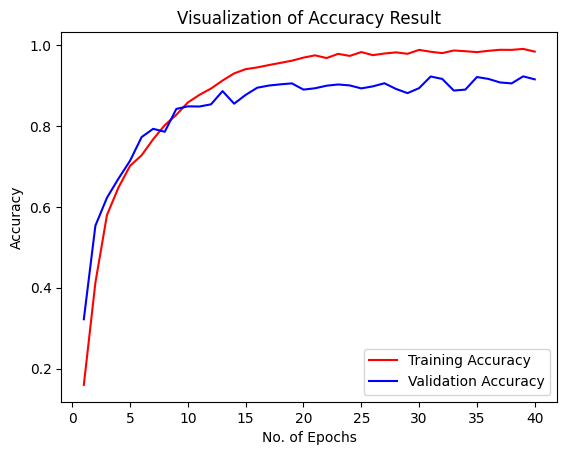

In [ ]:
#Visualization of Accuracy
import matplotlib.pyplot as plt
epochs = [i for i in range(1,41)]
plt.plot(epochs,training_history.history['accuracy'],label="Training Accuracy",color='red')
plt.plot(epochs,training_history.history['val_accuracy'],label="Validation Accuracy",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

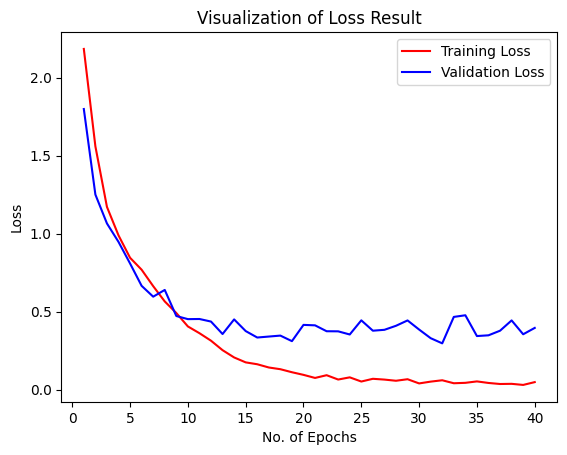

In [ ]:

#Visualization of Loss
epochs = [i for i in range(1,41)]
plt.plot(epochs,training_history.history['loss'],label="Training Loss",color='red')
plt.plot(epochs,training_history.history['val_loss'],label="Validation Loss",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

#Evaluating the Model

In [ ]:
# from tensorflow.keras.utils import to_categorical

# # One-hot encode labels
# num_classes = len(classes)  # Ensure this is set correctly
# y_test_one_hot = to_categorical(Y_test)

# print(f"\nX_test shape: {X_test.shape}")
# print(f"\ny_test_one_hot shape: {y_test_one_hot.shape}")

# no need as y_tets is already one hot encoded

In [ ]:
Y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
#Evaluate the model
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"\n📊 **Evaluation Results:**")
print(f"✅ Test Loss: {loss:.4f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9148 - loss: 0.3701

📊 **Evaluation Results:**
✅ Test Loss: 0.3959
✅ Test Accuracy: 0.9149


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#Generate predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded `y_test` back to class labels
y_test_labels = np.argmax(Y_test, axis=1)

#Compute Performance Metrics
precision = precision_score(y_test_labels, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test_labels, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test_labels, y_pred, average='weighted', zero_division=0)

print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-Score: {f1:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
 Precision: 0.9168
 Recall: 0.9149
 F1-Score: 0.9141


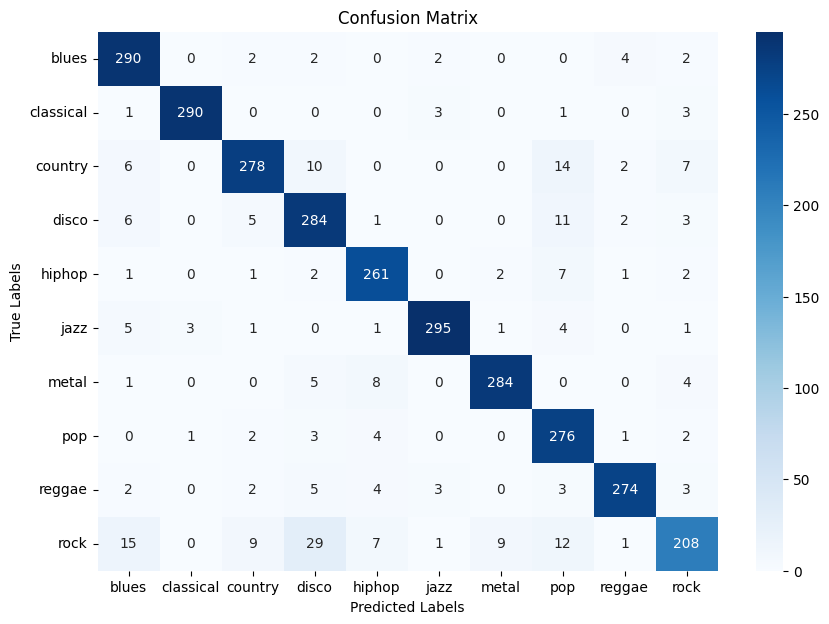

In [ ]:
#Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test_labels, y_pred)

import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/optimizer_lessmodel.h5', include_optimizer=False)

In [ ]:
#Recording History in json
import json
with open('training_hist_optimizer_less.json','w') as f:
  json.dump(training_history.history,f)